# Лабораторна робота 1

**Датасет:** CIC-IDS2017

In [92]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Завантаження та первинний аналіз даних

In [93]:
df = pd.read_csv('Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv')

df.columns = df.columns.str.strip()
df['Label'] = df['Label'].str.strip().str.replace('\ufffd', '-', regex=False)

df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


## Розмір датасета та назви колонок

In [94]:
print('Size:', df.shape)
print()
print(list(df.columns))

Size: (170366, 79)

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Cou

Цільова змінна - `Label`

In [95]:
TARGET = 'Label'
features = [c for c in df.columns if c != TARGET]

print('Features:', len(features))

Features: 78


## Типи даних

In [96]:
print(df.dtypes.value_counts())

int64      54
float64    24
str         1
Name: count, dtype: int64


## Розподіл за класами

In [97]:
counts = df[TARGET].value_counts()
print(pd.DataFrame({'Count': counts,
                    'Percent, %': (counts / len(df) * 100).round(2)}))

                             Count  Percent, %
Label                                         
BENIGN                      168186       98.72
Web Attack - Brute Force      1507        0.88
Web Attack - XSS               652        0.38
Web Attack - Sql Injection      21        0.01


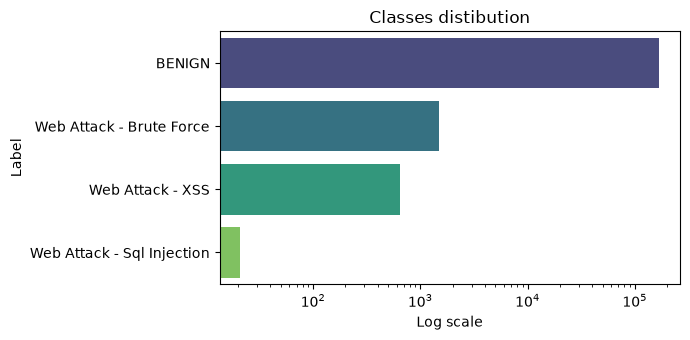

In [98]:
plt.figure(figsize=(7, 3.5))
sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette='viridis', legend=False)
plt.xscale('log')
plt.xlabel('Log scale')
plt.title('Classes distibution')
plt.tight_layout()
plt.show()

# 2. Попередня обробка даних

## Перевірка пропущених значень

In [99]:
num_cols = df.select_dtypes(include=[np.number]).columns

nan_counts = df.isna().sum()
inf_counts = np.isinf(df[num_cols]).sum()

print('NaN:')
print(nan_counts[nan_counts > 0])
print()
print('inf:')
print(inf_counts[inf_counts > 0])

NaN:
Flow Bytes/s    20
dtype: int64

inf:
Flow Bytes/s      115
Flow Packets/s    135
dtype: int64


In [100]:
df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print('NaN:', df.isna().sum().sum(), ' inf:', np.isinf(df[num_cols]).sum().sum())

NaN: 0  inf: 0


## Видалення константних ознак

In [101]:
const_cols = [c for c in features if df[c].nunique() == 1]
print('Const features:', len(const_cols))
print(const_cols)

df = df.drop(columns=const_cols)
print()
print('Dataset size:', df.shape)

Const features: 10
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Dataset size: (170366, 69)


In [102]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label_enc'] = le.fit_transform(df[TARGET])
df['Label_bin'] = (df[TARGET] != 'BENIGN').astype(int)

print(dict(enumerate(le.classes_)))

{0: 'BENIGN', 1: 'Web Attack - Brute Force', 2: 'Web Attack - Sql Injection', 3: 'Web Attack - XSS'}


# 3. Візуалізація та дослідження даних (EDA)

In [103]:
num_features = [c for c in df.columns if c not in [TARGET, 'Label_enc', 'Label_bin']]

corr_target = df[num_features].corrwith(df['Label_bin']).abs().sort_values(ascending=False)
top10 = corr_target.head(10).index.tolist()
top6 = top10[:6]

print(corr_target.head(10).round(3))

Init_Win_bytes_backward    0.259
PSH Flag Count             0.182
Init_Win_bytes_forward     0.176
Down/Up Ratio              0.124
min_seg_size_forward       0.115
Min Packet Length          0.095
Bwd Packet Length Min      0.083
Fwd Packet Length Min      0.068
Fwd IAT Std                0.064
Average Packet Size        0.060
dtype: float64


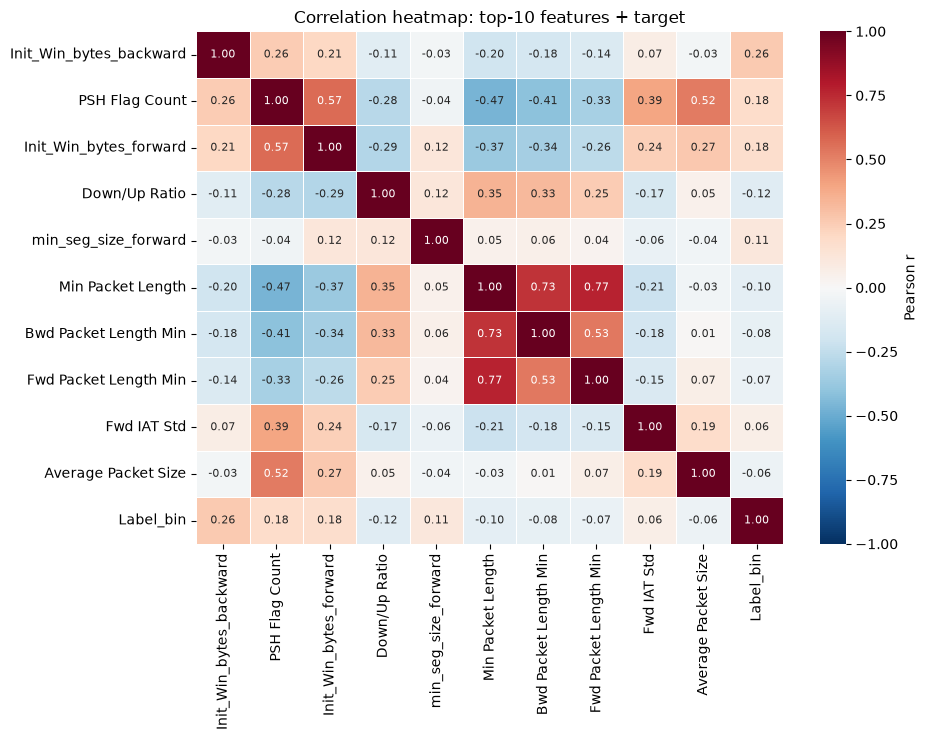

In [104]:
plt.figure(figsize=(9.5, 7.5))
sns.heatmap(df[top10 + ['Label_bin']].corr(), annot=True, fmt='.2f', annot_kws={'size': 8},
            cmap='RdBu_r', vmin=-1, vmax=1, center=0, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Correlation heatmap: top-10 features + target')
plt.tight_layout()
plt.show()

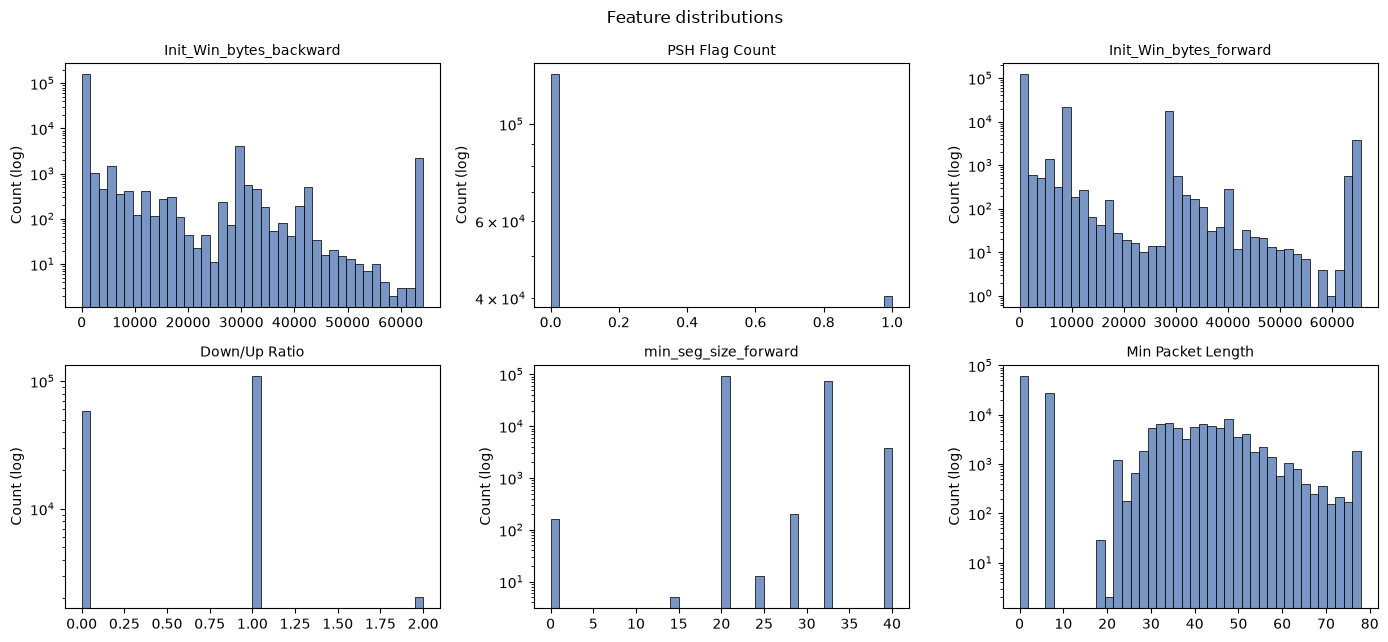

In [105]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))

for ax, col in zip(axes.flat, top6):
    sns.histplot(df[col].clip(upper=df[col].quantile(0.99)), bins=40, color='#4C72B0', ax=ax)
    ax.set_yscale('log')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Count (log)')

fig.suptitle('Feature distributions')
plt.tight_layout()
plt.show()

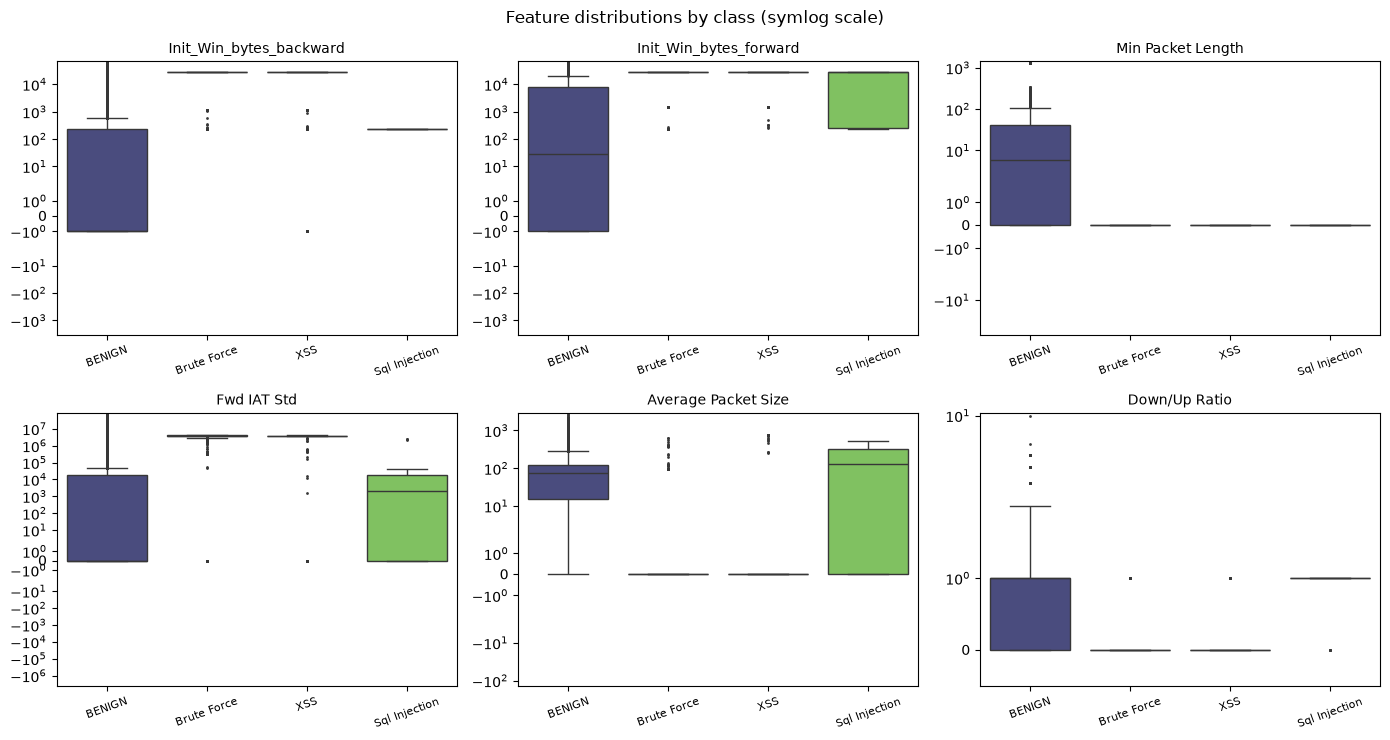

In [106]:
df['Label_short'] = df[TARGET].str.replace('Web Attack - ', '', regex=False)
order = ['BENIGN', 'Brute Force', 'XSS', 'Sql Injection']

box_features = ['Init_Win_bytes_backward', 'Init_Win_bytes_forward', 'Min Packet Length',
                'Fwd IAT Std', 'Average Packet Size', 'Down/Up Ratio']

fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))

for ax, col in zip(axes.flat, box_features):
    sns.boxplot(data=df, x='Label_short', y=col, order=order, hue='Label_short',
                hue_order=order, palette='viridis', legend=False, fliersize=1, ax=ax)
    ax.set_yscale('symlog')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelrotation=20, labelsize=8)

fig.suptitle('Feature distributions by class (symlog scale)')
plt.tight_layout()
plt.show()

In [107]:
print(df.groupby('Label_short')[box_features].median().T)

Label_short              BENIGN  Brute Force  Sql Injection           XSS
Init_Win_bytes_backward   -1.00     28960.00     235.000000  2.896000e+04
Init_Win_bytes_forward    29.00     29200.00   29200.000000  2.920000e+04
Min Packet Length          6.00         0.00       0.000000  0.000000e+00
Fwd IAT Std                0.00   3825759.52    2168.235227  3.794528e+06
Average Packet Size       74.25         0.00     131.625000  0.000000e+00
Down/Up Ratio              1.00         0.00       1.000000  0.000000e+00


# 4. Підготовка даних до навчання

In [108]:
attacks = df[df['Label_bin'] == 1]
benign = df[df['Label_bin'] == 0].sample(n=len(attacks), random_state=42)

data = pd.concat([attacks, benign]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Working sample:', data.shape)
print(data['Label_short'].value_counts())

Working sample: (4360, 72)
Label_short
BENIGN           2180
Brute Force      1507
XSS               652
Sql Injection      21
Name: count, dtype: int64


## Матриця ознак і цільова змінна

In [109]:
leak_cols = [TARGET, 'Label_short', 'Label_enc', 'Label_bin']

X = data.drop(columns=leak_cols)
y = data['Label_bin']

print('X:', X.shape, '  y:', y.shape)

X: (4360, 68)   y: (4360,)


## Розділення на train і test

In [110]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print('Train:', X_train.shape, ' benign:', int((y_train == 0).sum()), ' attacks:', int(y_train.sum()))
print('Test: ', X_test.shape, ' benign:', int((y_test == 0).sum()), ' attacks:', int(y_test.sum()))

Train: (3052, 68)  benign: 1526  attacks: 1526
Test:  (1308, 68)  benign: 654  attacks: 654


## Масштабування ознак

In [111]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)

X_train_sc = scaler.transform(X_train)
X_test_sc = scaler.transform(X_test)

print('mean ~ 0:', X_train_sc.mean().round(3), '  std ~ 1:', X_train_sc.std().round(3))
print('X_train_sc:', X_train_sc.shape, '  X_test_sc:', X_test_sc.shape)

mean ~ 0: 0.0   std ~ 1: 0.985
X_train_sc: (3052, 68)   X_test_sc: (1308, 68)


# 5. Навчання моделей

In [112]:
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

SCALED = {'kNN', 'SVM'}  

def make_models():
    return {
        'kNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
        'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
        'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
        'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    }

def fit_all(X_raw, X_scaled, y_fit):
    fitted = {}
    for name, model in make_models().items():
        train_data = X_scaled if name in SCALED else X_raw
        start = time.time()
        model.fit(train_data, y_fit)
        fitted[name] = model
        print(f'{name:15s} trained in {time.time() - start:6.2f} s')
    return fitted

In [113]:
models = fit_all(X_train, X_train_sc, y_train)

kNN             trained in   0.00 s
Decision Tree   trained in   0.01 s
SVM             trained in   0.04 s
Random Forest   trained in   0.20 s
AdaBoost        trained in   0.42 s


**Коментар.** kNN «навчається» миттєво — він лише запам'ятовує вибірку, усі обчислення в нього на етапі передбачення. Найдовше будуються ансамблі, причому AdaBoost не паралелиться: кожне дерево вчиться на помилках попереднього. На зменшеній вибірці це все одно секунди.

# 6. Підбір гіперпараметрів

## kNN: вибір n_neighbors

In [114]:
from sklearn.model_selection import cross_val_score, GridSearchCV

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 25, 31]
k_scores = []

for k in k_values:
    score = cross_val_score(KNeighborsClassifier(n_neighbors=k, n_jobs=-1),
                            X_train_sc, y_train, cv=5, scoring='f1').mean()
    k_scores.append(score)
    print(f'k = {k:3d}   F1 (CV) = {score:.4f}')

best_k = k_values[int(np.argmax(k_scores))]
print()
print('Best k:', best_k)

k =   1   F1 (CV) = 0.9944
k =   3   F1 (CV) = 0.9932
k =   5   F1 (CV) = 0.9919
k =   7   F1 (CV) = 0.9886
k =   9   F1 (CV) = 0.9863
k =  11   F1 (CV) = 0.9837
k =  15   F1 (CV) = 0.9812
k =  21   F1 (CV) = 0.9730
k =  25   F1 (CV) = 0.9692
k =  31   F1 (CV) = 0.9664

Best k: 1


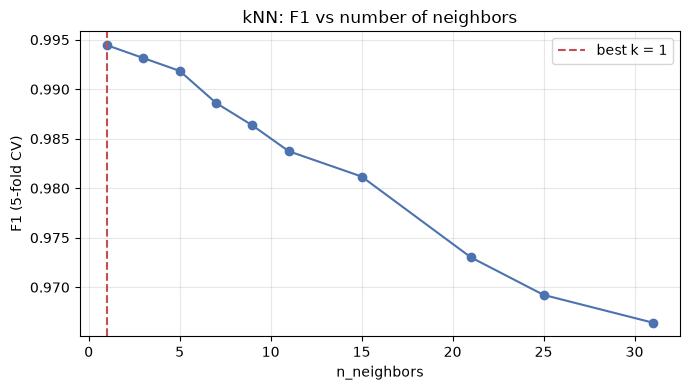

In [115]:
plt.figure(figsize=(7, 4))
plt.plot(k_values, k_scores, marker='o', color='#4C72B0')
plt.axvline(best_k, color='#C44E52', linestyle='--', label=f'best k = {best_k}')
plt.xlabel('n_neighbors')
plt.ylabel('F1 (5-fold CV)')
plt.title('kNN: F1 vs number of neighbors')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [116]:
knn_best = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1).fit(X_train_sc, y_train)

## SVM: GridSearchCV по C і gamma

In [117]:
param_grid = {'C': [0.1, 1, 10, 100],
              'gamma': ['scale', 0.01, 0.1, 1]}

grid = GridSearchCV(SVC(kernel='rbf', random_state=42), param_grid,
                    scoring='f1', cv=5, n_jobs=-1)
grid.fit(X_train_sc, y_train)

print('Best params:', grid.best_params_)
print('Best F1 (CV): %.4f' % grid.best_score_)

svm_best = grid.best_estimator_

Best params: {'C': 100, 'gamma': 1}
Best F1 (CV): 0.9914


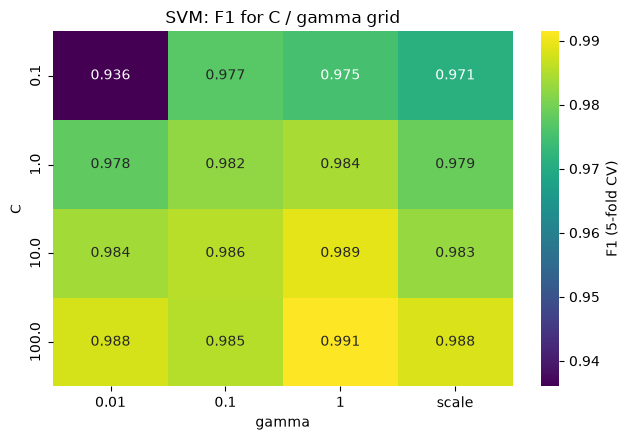

In [118]:
cv_res = pd.DataFrame(grid.cv_results_)
cv_res['param_gamma'] = cv_res['param_gamma'].astype(str)

pivot = cv_res.pivot_table(index='param_C', columns='param_gamma', values='mean_test_score')

plt.figure(figsize=(6.5, 4.5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis',
            cbar_kws={'label': 'F1 (5-fold CV)'})
plt.title('SVM: F1 for C / gamma grid')
plt.xlabel('gamma')
plt.ylabel('C')
plt.tight_layout()
plt.show()

In [119]:
depths = [2, 3, 5, 7, 10, 15, 20, None]
depth_scores = {}

for d in depths:
    depth_scores[d] = cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42),
                                      X_train, y_train, cv=5, scoring='f1').mean()
    print(f'max_depth = {str(d):4s}   F1 (CV) = {depth_scores[d]:.4f}')

best_depth = max(depth_scores, key=depth_scores.get)
print()
print('Best max_depth:', best_depth)

max_depth = 2      F1 (CV) = 0.9375
max_depth = 3      F1 (CV) = 0.9858
max_depth = 5      F1 (CV) = 0.9915
max_depth = 7      F1 (CV) = 0.9928
max_depth = 10     F1 (CV) = 0.9935
max_depth = 15     F1 (CV) = 0.9935
max_depth = 20     F1 (CV) = 0.9935
max_depth = None   F1 (CV) = 0.9935

Best max_depth: 10


In [120]:
for n in [10, 50, 100, 200, 400]:
    score = cross_val_score(RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1),
                            X_train, y_train, cv=5, scoring='f1').mean()
    print(f'n_estimators = {n:3d}   F1 (CV) = {score:.4f}')

n_estimators =  10   F1 (CV) = 0.9954
n_estimators =  50   F1 (CV) = 0.9961
n_estimators = 100   F1 (CV) = 0.9971
n_estimators = 200   F1 (CV) = 0.9967
n_estimators = 400   F1 (CV) = 0.9964


# 7. Порівняння та оцінювання моделей

In [121]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

final_models = dict(models)
final_models['kNN (tuned)'] = knn_best
final_models['SVM (tuned)'] = svm_best

def test_data_for(name):
    return X_test_sc if name.split(' ')[0] in SCALED else X_test

preds = {name: model.predict(test_data_for(name)) for name, model in final_models.items()}

scores = pd.DataFrame([{
    'Model': name,
    'Accuracy': accuracy_score(y_test, p),
    'Precision': precision_score(y_test, p),
    'Recall': recall_score(y_test, p),
    'F1': f1_score(y_test, p),
} for name, p in preds.items()]).set_index('Model').sort_values('F1', ascending=False)

print(scores.round(4))

               Accuracy  Precision  Recall      F1
Model                                             
AdaBoost         0.9962     0.9924  1.0000  0.9962
Decision Tree    0.9946     0.9909  0.9985  0.9947
Random Forest    0.9946     0.9939  0.9954  0.9947
kNN (tuned)      0.9916     0.9879  0.9954  0.9916
SVM (tuned)      0.9901     0.9938  0.9862  0.9900
kNN              0.9878     0.9819  0.9939  0.9878
SVM              0.9778     0.9713  0.9847  0.9780


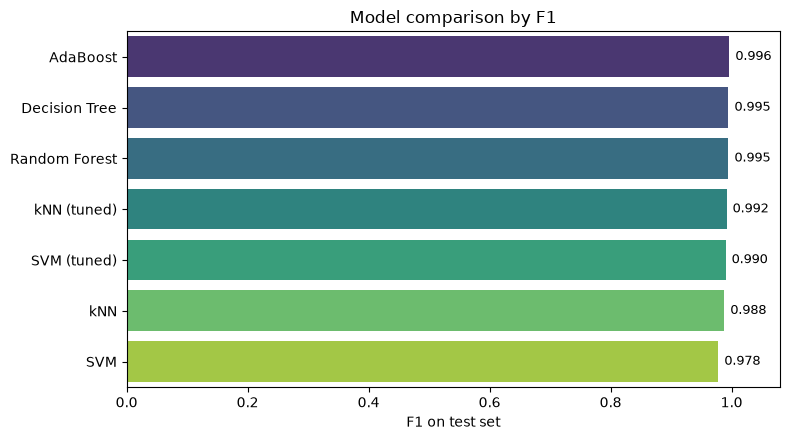

In [122]:
plt.figure(figsize=(8, 4.5))
sns.barplot(x=scores['F1'], y=scores.index, hue=scores.index, palette='viridis', legend=False)
plt.xlim(0, 1.08)
plt.xlabel('F1 on test set')
plt.ylabel('')
plt.title('Model comparison by F1')

for i, value in enumerate(scores['F1']):
    plt.text(value + 0.01, i, f'{value:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## classification_report

In [123]:
for name, p in preds.items():
    print(name)
    print(classification_report(y_test, p, target_names=['BENIGN', 'Attack'], digits=4))

kNN
              precision    recall  f1-score   support

      BENIGN     0.9938    0.9817    0.9877       654
      Attack     0.9819    0.9939    0.9878       654

    accuracy                         0.9878      1308
   macro avg     0.9878    0.9878    0.9878      1308
weighted avg     0.9878    0.9878    0.9878      1308

Decision Tree
              precision    recall  f1-score   support

      BENIGN     0.9985    0.9908    0.9946       654
      Attack     0.9909    0.9985    0.9947       654

    accuracy                         0.9946      1308
   macro avg     0.9947    0.9946    0.9946      1308
weighted avg     0.9947    0.9946    0.9946      1308

SVM
              precision    recall  f1-score   support

      BENIGN     0.9845    0.9709    0.9777       654
      Attack     0.9713    0.9847    0.9780       654

    accuracy                         0.9778      1308
   macro avg     0.9779    0.9778    0.9778      1308
weighted avg     0.9779    0.9778    0.9778      130

## confusion_matrix

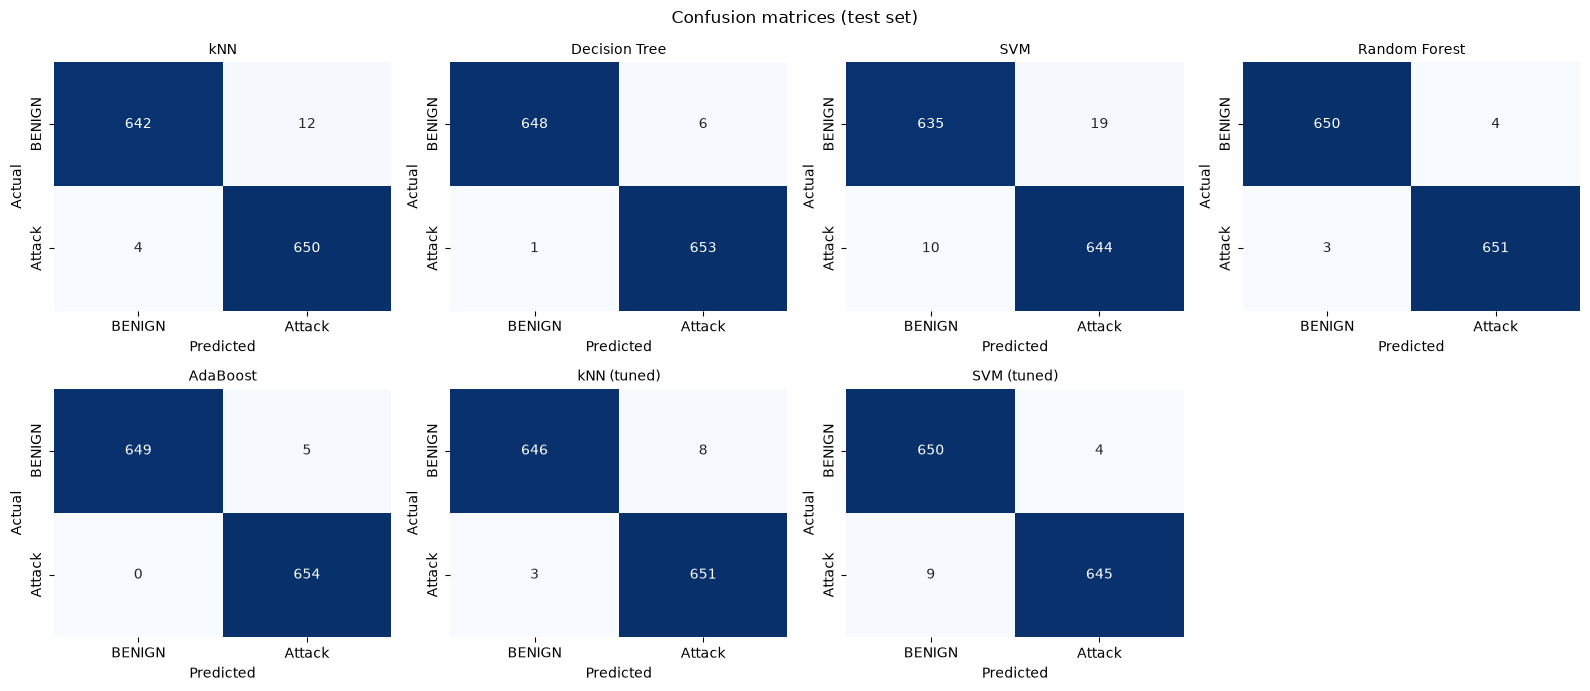

In [124]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for ax, (name, p) in zip(axes.flat, preds.items()):
    sns.heatmap(confusion_matrix(y_test, p), annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['BENIGN', 'Attack'], yticklabels=['BENIGN', 'Attack'], ax=ax)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

for ax in list(axes.flat)[len(preds):]:
    ax.axis('off')

fig.suptitle('Confusion matrices (test set)')
plt.tight_layout()
plt.show()

In [125]:
best_name = scores.index[0]

print('Best model by F1:', best_name)
print(confusion_matrix(y_test, preds[best_name]))

Best model by F1: AdaBoost
[[649   5]
 [  0 654]]


### Висновок

Усі моделі помиляються менш ніж у 3 % випадків. Атаки виконувались одним інструментом і залишили характерний слід як однаковий розмір TCP-вікна, увімкнений прапорець PSH, однакові паузи між пакетами.

Найкращий AdaBoost. Далі Decision Tree і Random Forest. kNN і SVM слабші, бо порівнюють потоки за відстанню одразу по всіх 68 ознаках, а корисних серед них близько десятка.

Застереження: вибірка була штучно збалансована. У реальній мережі атак близько 1 %, тому хибних тривог буде помітно більше.